### DSBA M1
## Econometrics
Prof. Roberto Renò - ESSEC Business School 

## Homework 1

In [8]:
!python3 -m pip install statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [9]:
import numpy as np
import pandas as pd

In [10]:
data_in = ""
data = pd.read_csv(data_in + "bwages.csv")

In [11]:
data

,WAGE,LNWAGE,EDUC,EXPER,LNEXPER,LNEDUC,MALE
0,7.780208,2.051583,1,23,3.178054,0.000000,1
1,4.818505,1.572464,1,15,2.772589,0.000000,0
2,10.563645,2.357418,1,31,3.465736,0.000000,1
3,7.042429,1.951953,1,32,3.496508,0.000000,1
4,7.887521,2.065282,1,9,2.302585,0.000000,1
...,...,...,...,...,...,...,...
1467,11.119626,2.408712,5,1,0.693147,1.609438,1
1468,5.453375,1.696235,5,14,2.708050,1.609438,0
1469,11.085489,2.405637,5,19,2.995732,1.609438,0
1470,15.649843,2.750461,5,15,2.772589,1.609438,0


## Explaining wages

We model individual wages using a cross-sectional data set of 1472 observations. The dataset is called BWAGES and the variables we use are:

• wage: hourly wage rate in euros per hous
• male: 1 if male, 0 if female
• educ: education level, 1 = primary school, 2 = lower vocational training, 3 = intermediate level, 4 = higher vocational training, 5 = university level
• exper: experience in years

## Questions 

Part A

1. Compute standard descriptive statistics for the variables involved in this study.
2. Prepare extra columns in the data dataframe with dummy variables: educ1=1 if primary school, 0 otherwise; educ2=1 if lower vocational training, 0 otherwise, and so on.
3. Estimate the following model by OLS: wage = β0 + β1male + β2educ1 + β3educ2 + β3educ3 + β4educ4 + β5exper + ε, and interpret the estimated coefficients.
4. Why is there no educ5 in the model? Explain.
5. What is the expected salary for a man with university level education?
6. Using standard t-tests, are the explanatory variables significant?
7. Is there a significant salary difference between men and woman according to the above model?
8. Add squared experience as an additional variable in your model, estimate it again, and show the new results.
9. What is the impact of experience on wage? Write a short comment based on the statistical significance of the above estimate.

Part B

The above model did not have any interaction effect between gender and education.

10. Write down a model that explicitly incorporates an interaction effect between gender and education.
11. Estimate this new model using OLS and interpret the new coefficients.
12. Test for differences between men and woman in this general model.
13. Demonstrate empirically that the sum of squared residuals (SSR) for this general model is equal to the SSR of the model explaining wage by the educ dummies and the experience variables fitted to the sample of men + the SSR of the same model fitted to the sample of woman.

Part C

14. Test for the heteroskedasticity of the residuals.
15. Perform generalized least squares if homoskedasticity is rejected.
16. Compute White standard errors for the model in point 2 and compare them with the OLS standard errors found in question 2. What has changed?
17. Compute also HC1, HC2, HC3: what are the differences?
18. How much is the correlation between estimated residuals and exper? Explain.
19. Display the the distribution of the residuals ε in the model in point 2. Test its normality.
20. If the previous question rejects, what do you think are the consequences for the tests performed in this study? Explain

## Part 1
## Question 1

In [12]:
data.describe()

,WAGE,LNWAGE,EDUC,EXPER,LNEXPER,LNEDUC,MALE
count,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000
mean,11.050616,2.334394,3.378397,17.217391,2.690671,1.136518,0.606658
std,4.450513,0.362535,1.204522,10.166675,0.729217,0.433971,0.488658
min,2.190978,0.784348,1.000000,0.000000,0.000000,0.000000,0.000000
25%,8.112878,2.093453,3.000000,9.000000,2.302585,1.098612,0.000000
50%,10.126653,2.315170,3.000000,16.500000,2.861792,1.098612,1.000000
75%,12.755447,2.545958,4.000000,24.000000,3.218876,1.386294,1.000000
max,47.575527,3.862318,5.000000,47.000000,3.871201,1.609438,1.000000


## Question 2

In [13]:
print(data.columns)

Index(['WAGE', 'LNWAGE', 'EDUC', 'EXPER', 'LNEXPER', 'LNEDUC', 'MALE'], dtype='str')


In [14]:
data['EDUC1'] = (data['EDUC'] == 1).astype(int)
data['EDUC2'] = (data['EDUC'] == 2).astype(int)
data['EDUC3'] = (data['EDUC'] == 3).astype(int)
data['EDUC4'] = (data['EDUC'] == 4).astype(int)
data['EDUC5'] = (data['EDUC'] == 5).astype(int)

data.head()

,WAGE,LNWAGE,EDUC,EXPER,LNEXPER,LNEDUC,MALE,EDUC1,EDUC2,EDUC3,EDUC4,EDUC5
0,7.780208,2.051583,1,23,3.178054,0.0,1,1,0,0,0,0
1,4.818505,1.572464,1,15,2.772589,0.0,0,1,0,0,0,0
2,10.563645,2.357418,1,31,3.465736,0.0,1,1,0,0,0,0
3,7.042429,1.951953,1,32,3.496508,0.0,1,1,0,0,0,0
4,7.887521,2.065282,1,9,2.302585,0.0,1,1,0,0,0,0


## Question 3

In [15]:
import statsmodels.api as sm

X = data[['MALE', 'EDUC1', 'EDUC2', 'EDUC3', 'EDUC4', 'EXPER']]
X = sm.add_constant(X)
y = data['WAGE']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   WAGE   R-squared:                       0.367
Model:                            OLS   Adj. R-squared:                  0.364
Method:                 Least Squares   F-statistic:                     141.5
Date:                Mon, 04 May 2026   Prob (F-statistic):          1.29e-141
Time:                        22:14:02   Log-Likelihood:                -3949.4
No. Observations:                1472   AIC:                             7913.
Df Residuals:                    1465   BIC:                             7950.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.4010      0.260     40.012      0.0

## Question 4

At first, we tried running the model with all five education dummies, but we quickly realized why educ5 has to be left out. It’s because of the Dummy Variable Trap and the issue of perfect multicollinearity. (Message from Python after computed with educ5)

Our model already includes an intercept (the constant term β 0). 
By definition, every single person in our dataset belongs to exactly one of the five education levels. This means that if you add up educ1 + educ2 + educ3 + educ4 + educ5, the sum is always 1 for every observation.

Since the constant in our regression is also a column of 1s, having all five dummies creates a situation where one variable is a perfect linear combination of the others. Mathematically, this makes the X′X matrix 'singular' (non-invertible), and the OLS estimator can't be calculated properly.

By dropping educ5, we turn educ5 into our base category (or reference group). Now, the intercept β 0 represents the average wage for someone with a university degree (educ5 group), and the coefficients for educ1 through educ4 tell us exactly how much (more or less) those groups earn compared to that university-level baseline. If we kept all five, we wouldn't have a reference point to compare them against

## Question 5

Wage = 10.4010+(1.3009×1)+(0.1907×exper)

Wage = 11.7019+0.1907×exper

Expected Salary for a man with univ level education is 11,70€/h, and + 0,19€ for each year of experience.

In [16]:
wage_base_male_univ = model.params['const'] + model.params['MALE']
print(f"Expected wage : {wage_base_male_univ:.4f} €/h")

Expected wage : 11.7019 €/h


## Question 6

Based on the p-values in the P>∣t∣ column in Question 3, all explanatory variables are statistically significant at the 5% level, as all p-values are below 0.05 (all at 0.00). This means that gender, all levels of education (relative to university), and experience each have a confirmed statistical impact on the hourly wage.

## Question 7

Based on the regression results, the answer is yes. To determine this, we have to specifically look at the male variable.

First, if you look at the coefficient for male (which is 1.3009 in my output), it’s positive. This tells us that, on average, men earn about 1.30€ more per hour than women. Here, this condition means that this gap exists even when comparing a man and a woman who have the exact same level of education and the same years of experience.

Second, to see if this gap is 'real' or just due to random noise in our specific sample of 1472 people, I checked the p-value (the P>∣t∣ column). The p-value for male is 0.000. Since this is way below the standard significance threshold of 0.05 (5%), we reject the null hypothesis (H0:β male=0).

The probability that this 1.30€ difference is just a coincidence is basically zero. So, the model proves there is a statistically significant 'gender premium' in this dataset, favoring men.

## Question 8

In [17]:
from ipaddress import summarize_address_range
data['EXPER2'] = data['EXPER']**2

X = data[['MALE', 'EDUC1', 'EDUC2', 'EDUC3', 'EDUC4', 'EXPER', 'EXPER2']]
X = sm.add_constant(X)
Y = data['WAGE']

model = sm.OLS(Y,X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   WAGE   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     128.3
Date:                Mon, 04 May 2026   Prob (F-statistic):          3.36e-147
Time:                        22:14:02   Log-Likelihood:                -3933.8
No. Observations:                1472   AIC:                             7884.
Df Residuals:                    1464   BIC:                             7926.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.3200      0.322     28.956      0.0

## Question 9

The impact of experience on wages is now non-linear, and the results are highly significant (with p-values of 0.000).

Specifically, the positive coefficient for exper (0.4859) and the negative coefficient for exper2 (−0.0075) indicate a concave relationship. This means that wages increase with experience, but they do so at a decreasing rate.

Statistically, this is very important: the 'return' on an extra year of experience is high at the beginning of a career, but it slowly diminishes over time. For example, the gain in wage for moving from 0 to 1 year of experience is much larger than the gain for moving from 30 to 31 years. 

# Part B

### Question 10
Write down a model that explicitly incorporates an interaction effect between gender and education.




In [18]:
data['GENDER-EDUC1'] = data['MALE']*data['EDUC1']
data['GENDER-EDUC2'] = data['MALE']*data['EDUC2']
data['GENDER-EDUC3'] = data['MALE']*data['EDUC3']
data['GENDER-EDUC4'] = data['MALE']*data['EDUC4']

X_interaction = data[['MALE', 'EDUC1', 'EDUC2', 'EDUC3', 'EDUC4', 'EXPER', 'EXPER2', 'GENDER-EDUC1', 'GENDER-EDUC2', 'GENDER-EDUC3', 'GENDER-EDUC4']]
X_interaction = sm.add_constant(X_interaction)
Y_interaction = data['WAGE']

### Question 11
Estimate this new model using OLS and interpret the new coefficients.


In [19]:
model_interaction = sm.OLS(Y_interaction,X_interaction).fit()

print(model_interaction.summary())

                            OLS Regression Results                            
Dep. Variable:                   WAGE   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     82.19
Date:                Mon, 04 May 2026   Prob (F-statistic):          3.22e-144
Time:                        22:14:02   Log-Likelihood:                -3931.2
No. Observations:                1472   AIC:                             7886.
Df Residuals:                    1460   BIC:                             7950.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            9.0210      0.378     23.869   

We can note that, in the continuity of our previous obersvation, we still have right skewed data with fat tail. The residuals are not generated from a normal distribution.

Yet, when we look at our new cross-variables GENDER-EDUC1-4, we on average larger standard errors, meaning the interval of confidence is larger and therefore our accuracy of estimating the true parameter lower. Moreover, what is interesting is that for all of those variables, the p-value we have does not allow use to reject the hypothesis that the gender gap for the education levels 1 to 4 are the same that for the gender gap of education level 5. The only reserve we can have is that the gender gap induced by a level of education of 3 has weak evidence.

### Question 12
Test for differences between men and woman in this general model.

In [20]:
# Gender Gap
wage_diff_gender_educ1 = model_interaction.params['GENDER-EDUC1']+model_interaction.params['MALE']
wage_diff_gender_educ2 = model_interaction.params['GENDER-EDUC2']+model_interaction.params['MALE']
wage_diff_gender_educ3 = model_interaction.params['GENDER-EDUC3']+model_interaction.params['MALE']
wage_diff_gender_educ4 = model_interaction.params['GENDER-EDUC4']+model_interaction.params['MALE']
wage_diff_gender_educ5 = +model_interaction.params['MALE']

wage_diff_gender_educ=[wage_diff_gender_educ1, wage_diff_gender_educ2, wage_diff_gender_educ3, wage_diff_gender_educ4, wage_diff_gender_educ5]
for i in range(len(wage_diff_gender_educ)):
    print(f"Difference in wage for Educ{i+1}: {wage_diff_gender_educ[i]:.4f} €/h")

Difference in wage for Educ1: 1.7981 €/h
Difference in wage for Educ2: 1.7272 €/h
Difference in wage for Educ3: 0.7526 €/h
Difference in wage for Educ4: 1.0859 €/h
Difference in wage for Educ5: 1.7655 €/h


In [21]:
# Difference in expected salary

def e_wage(educ_lvl, male):
    wage = (model_interaction.params['const']
    + model_interaction.params['EXPER'] * data['EXPER'].mean()
    + model_interaction.params['EXPER2'] * data['EXPER2'].mean()
    + (model_interaction.params['MALE'] if male else 0)
    + (model_interaction.params.get(f'GENDER-EDUC{educ_lvl}', 0) if male else 0)
    + model_interaction.params.get(f'EDUC{educ_lvl}', 0)
    )
    return round(wage,2)

for i in range(1,6):
    print(f'For an education level of {i}, the expected wage of women is {e_wage(i,False)} €/h, the expected wage of men is {e_wage(i,True)} €/h')


For an education level of 1, the expected wage of women is 5.5 €/h, the expected wage of men is 7.3 €/h
For an education level of 2, the expected wage of women is 7.25 €/h, the expected wage of men is 8.98 €/h
For an education level of 3, the expected wage of women is 9.75 €/h, the expected wage of men is 10.51 €/h
For an education level of 4, the expected wage of women is 11.36 €/h, the expected wage of men is 12.44 €/h
For an education level of 5, the expected wage of women is 13.44 €/h, the expected wage of men is 15.2 €/h


### Question 13
Demonstrate empirically that the sum of squared residuals (SSR) for this general model is equal to the SSR of the model explaining wage by the educ dummies and the experience variables fitted to the sample of men + the SSR of the same model fitted to the sample of woman.


In [22]:
# Full residuals
X = data[['EDUC1', 'EDUC2', 'EDUC3', 'EDUC4', 'EXPER', 'EXPER2']]
X = sm.add_constant(X)
Y = data['WAGE']
model_full = sm.OLS(Y,X).fit()
SSR_full = model_full.ssr
SSR_interaction = model_interaction.ssr

# Subsample residuals
res = model_full.resid
res_inter= model_interaction.resid

res_male = res[data['MALE'] == 1]
res_female = res[data['MALE'] == 0]
res_intermale= res_inter[data['MALE']==1]
res_interfemale= res_inter[data['MALE']==0]

SSR_male = (res_male**2).sum()
SSR_female = (res_female**2).sum()
SSR_intermale = (res_intermale**2).sum()
SSR_interfemale = (res_interfemale**2).sum()

print(f"Full SSR:          {SSR_full:.2f}")
print(f"Male SSR:          {SSR_male:.2f}")
print(f"Female SSR:        {SSR_female:.2f}")
print(f"Sum:               {SSR_male + SSR_female:.2f}")
print("___________________________________________________")
print(f"Interaction SSR:   {SSR_interaction:.2f}")
print(f"Male SSR:          {SSR_intermale:.2f}")
print(f"Female SSR:        {SSR_interfemale:.2f}")
print(f"Sum:               {SSR_intermale + SSR_interfemale:.2f}")

Full SSR:          18606.95
Male SSR:          12772.57
Female SSR:        5834.38
Sum:               18606.95
___________________________________________________
Interaction SSR:   17994.05
Male SSR:          12565.77
Female SSR:        5428.27
Sum:               17994.05


When we estimate the general model with only education dummies and experience on the full sample, the SSR decomposes exactly into the sum of the SSRs for men and women because the residuals come from the same specification and the same coefficients.
For the extended model with gender and interaction terms, the SSR is different since it is a different specification and the regressors differ systematically by gender, but the identity still applies.

# Part C

For the entirety of Part C, the reference model is the one estimated in Question 8.

### Question 14

In [35]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, het_white

# Extract residuals and explanatory variables from the model
resids = model.resid
exog = model.model.exog

# Breusch-Pagan Test
bp_test = het_breuschpagan(resids, exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']

print("Breusch-Pagan Test:")
for name, value in zip(labels, bp_test):
    print(f"{name}: {value:.4f}")

# White Test
white_test = het_white(resids, exog)

print("\nWhite Test:")
for name, value in zip(labels, white_test):
    print(f"{name}: {value:.4f}")

Breusch-Pagan Test:
LM Statistic: 100.2826
LM-Test p-value: 0.0000
F-Statistic: 15.2899
F-Test p-value: 0.0000

White Test:
LM Statistic: 137.4116
LM-Test p-value: 0.0000
F-Statistic: 6.4821
F-Test p-value: 0.0000


Both tests (Breusch-Pagan and White) have p-values of 0.0000, which is well below the threshold of 0.05. We can therefore reject the null hypothesis of homoskedasticity. The residuals are therefore heteroskedastic, which means that our OLS standard errors are not valid. We must correct them by using robust standard errors or GLS.

### Question 15

In [36]:
X_complet = data[['MALE', 'EDUC1', 'EDUC2', 'EDUC3', 'EDUC4', 'EXPER', 'EXPER2']]
X_complet = sm.add_constant(X_complet)

# Squared residuals from original model
sq_resids = model.resid**2

# Estimate the variance function
var_model = sm.OLS(np.log(sq_resids), X_complet).fit()

# Compute weights
est_variance = np.exp(var_model.fittedvalues)
weights = 1 / est_variance

# Fit the Generalized Least Squares (WLS) model
gls_model = sm.WLS(y, X_complet, weights=weights).fit()

print(gls_model.summary())

                            WLS Regression Results                            
Dep. Variable:                   WAGE   R-squared:                       0.382
Model:                            WLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     129.2
Date:                Mon, 04 May 2026   Prob (F-statistic):          5.11e-148
Time:                        23:26:36   Log-Likelihood:                -3700.8
No. Observations:                1472   AIC:                             7418.
Df Residuals:                    1464   BIC:                             7460.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.3423      0.270     34.552      0.0

We have rejected the assumption of homoskedasticity. The standard OLS estimator is therefore no longer efficient, and its standard errors are invalid. We must therefore apply the Generalised Least Squares (GLS) method, and more specifically Weighted Least Squares (WLS), whilst using a Feasible GLS approach. To do this, we must estimate the error variance by regressing the log of the squared OLS residuals on the explanatory variables. We must then run a regression weighted by the inverse of this estimated variance. Unlike robust standard errors, this new approach (WLS) transforms the estimated coefficients themselves and provides more efficient estimators under the assumption that the variance model is correctly specified. This allows us to account for heteroskedasticity and improve the overall efficiency of the model.

### Question 16

In [ ]:
# Standard OLS model
model_ols_q8 = sm.OLS(y, X_complet).fit()

# OLS with White (HC0) robust standard errors
model_white = sm.OLS(y, X_complet).fit(cov_type='HC0')

# Compare standard errors
comparison = pd.DataFrame({
    'OLS Std. Errors': model_ols_q8.bse,
    'White Std. Errors (HC0)': model_white.bse,
    'Difference (%)': ((model_white.bse - model_ols_q8.bse) / model_ols_q8.bse) * 100
})

print(comparison)

Standard Errors Comparison:
        OLS Std. Errors  White Std. Errors (HC0)  Difference (%)
const          0.321862                 0.295703       -8.127185
MALE           0.192738                 0.184547       -4.249497
EDUC1          0.416928                 0.399023       -4.294555
EDUC2          0.295891                 0.352393       19.095431
EDUC3          0.259185                 0.327363       26.304786
EDUC4          0.269535                 0.322220       19.546434
EXPER          0.031667                 0.034695        9.562502
EXPER2         0.000798                 0.000997       24.900300


When we compare the standard errors, we can see that there have been significant changes. This confirms our previous findings regarding heteroscedasticity. The estimated coefficients remain the same, but the standard errors for most variables have increased significantly (e.g. EDUC3 and EXPER2). Conversely, the standard errors for a few variables have decreased slightly (e.g. MALE and EDUC1). Since the standard error is used to calculate the t-statistic, these new robust standard errors directly alter the t-ratios and confidence intervals. This provides a more reliable inference than the uncorrected OLS model.

### Question 17

In [38]:
# Compare OLS and all robust standard errors (HC0 to HC3) for the Q8 model
comparison_hc = pd.DataFrame({
    'OLS': model_ols_q8.bse,
    'HC0': model_ols_q8.HC0_se,
    'HC1': model_ols_q8.HC1_se,
    'HC2': model_ols_q8.HC2_se,
    'HC3': model_ols_q8.HC3_se
})

print("Comparison of Robust Standard Errors:")
print(comparison_hc)

Comparison of Robust Standard Errors:
             OLS       HC0       HC1       HC2       HC3
const   0.321862  0.295703  0.296510  0.297039  0.298392
MALE    0.192738  0.184547  0.185051  0.185074  0.185604
EDUC1   0.416928  0.399023  0.400112  0.400567  0.402122
EDUC2   0.295891  0.352393  0.353355  0.353401  0.354415
EDUC3   0.259185  0.327363  0.328256  0.328210  0.329060
EDUC4   0.269535  0.322220  0.323099  0.323065  0.323914
EXPER   0.031667  0.034695  0.034789  0.034970  0.035249
EXPER2  0.000798  0.000997  0.000999  0.001006  0.001015


As might be expected with a large sample (n=1472), the differences between the robust estimators are small. HC1 applies a small degrees-of-freedom correction and has an error only slightly larger than HC0. HC2 and HC3 adjust for leverage, with HC3 in particular providing the most conservative estimates, as can be seen with EDUC1, for example, where HC3 is 0.402 and HC0 is 0.399. However, all robust errors remain very different from those of the uncorrected OLS

### Question 18

In [40]:
# Correlation between EXPER and the residuals of the OLS model
correlation = data['EXPER'].corr(model_ols_q8.resid)

print(f"Correlation: {correlation}")

Correlation: 5.042162452081969e-15


The correlation between the estimated residuals and the explanatory variable is very close to 0 (5.042162452081969e-15). According to the first-order conditions, the estimated residuals are mathematically orthogonal to all explanatory variables in the model. The sample correlation between the predictors and the OLS residuals is therefore exactly 0.

### Question 19

In [45]:
!python3 -m pip install matplotlib seaborn scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 619.2 kB/s  0:00:13m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 191.9 kB/s  0:00:13 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 144.2 kB/s  0:00:52 eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m6/8 [matplotlib]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


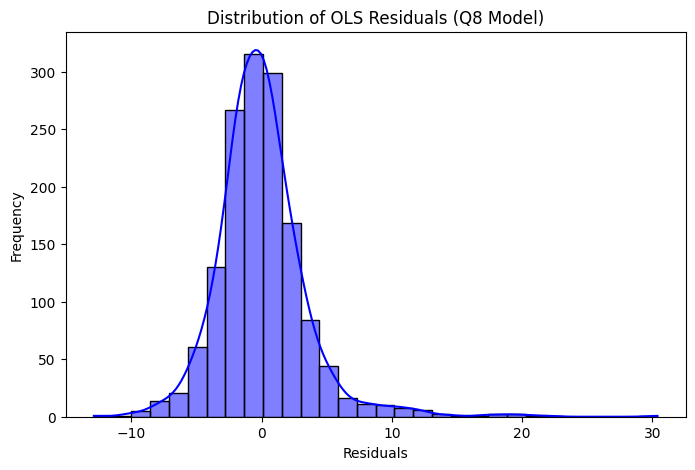

Jarque-Bera Normality Test:
Jarque-Bera Statistic: 5377.2869
p-value: 0.0000e+00


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Extract residuals from the reference model (Q8)
residuals = model_ols_q8.resid

# Plot of the distribution of residuals
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=30, color='blue')
plt.title('Distribution of OLS Residuals (Q8 Model)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Jarque-Bera test for normality
jb_stat, jb_pvalue = stats.jarque_bera(residuals)

print("Jarque-Bera Normality Test:")
print(f"Jarque-Bera Statistic: {jb_stat:.4f}")
print(f"p-value: {jb_pvalue:.4e}")

To assess the normality of the estimated residuals, we must analyse their distribution. Visually, the histogram shows a distribution centred around 0 but which is not perfectly symmetrical. It has a very sharp central peak (leptokurtic) and a long right tail (positive skewness).

The Jarque-Bera Normality Test confirms our visual analysis. The null hypothesis H0 assumes that the residuals are normally distributed. With a Jarque-Bera statistic of 5377.29 and a p-value of 0.0000, we can reject the null hypothesis and therefore conclude that the residuals are not normally distributed.

### Question 20

We have seen that the Jarque-Bera test rejects the null hypothesis of normality. The exact finite-sample properties of our model no longer hold. The residuals are not normally distributed, so the finite-sample results based on the assumption of normality are no longer valid.

However, the consequences of these tests are negligible due to the large sample size (n=1472). Normality is restored in the asymptotic distribution and, using the central limit theorem, the OLS estimators exhibit conditional asymptotic normality, which means that the normality of the errors is not required.

As long as we are concerned with these large-sample asymptotic properties, our statistical inferences, such as t-tests and confidence intervals, remain fully valid, particularly because we have already corrected for heteroskedasticity by using robust standard errors.